# Tuning hyperparameters

Set directory

In [1]:
import sys
import os

# Find the project root (Speciale_Kode)
current_dir = os.getcwd()
project_root = current_dir

# Looks for "Speciale_Kode" folder:
while os.path.basename(project_root) != "Speciale_Kode":
    project_root = os.path.dirname(project_root)

# Add to Python path
if project_root not in sys.path:
    sys.path.append(project_root)

Load data:

In [2]:
from Modules.read_data import read_data
import pandas as pd
from pathlib import Path

(
    DK1_train,
    DK1_test,
    DK2_train,
    DK2_test,
    DK1_train_weather,
    DK1_test_weather,
    DK2_train_weather,
    DK2_test_weather
) = read_data("combined_data_cleaned_v5.csv")
print(f"Features: {DK1_train.columns.tolist()}")

def _load_feature_predictions_for_zone(zone):
    prediction_path = Path(project_root) / "Data" / f"feature_predictions_{zone}_2024-2025.csv"
    if not prediction_path.exists():
        print("No precomputed forecasts found.")
        return None

    predictions = pd.read_csv(prediction_path, decimal=",", sep = ";", parse_dates=["Time"])
    predictions = predictions.loc[:, ~predictions.columns.duplicated()].copy()
    if "DKZone" in predictions.columns:
        predictions = predictions.loc[predictions["DKZone"] == zone].copy()
    return predictions


dk1_feature_predictions = _load_feature_predictions_for_zone("DK1")
dk2_feature_predictions = _load_feature_predictions_for_zone("DK2")
if (dk1_feature_predictions is not None) and (dk2_feature_predictions is not None):
    print("\nPrecomputed forecasts loaded.")

dk1_use_precomputed_feature_values = dk1_feature_predictions is not None
dk2_use_precomputed_feature_values = dk2_feature_predictions is not None

Notebook_dir: c:\Users\Christine\Documents\Python\Speciale_Kode\Modules
Python_dir: c:\Users\Christine\Documents\Python\Speciale_Kode
Data_folder: c:\Users\Christine\Documents\Python\Speciale_Kode\Data
Training data shape (DK1): (78888, 38)
Test data shape (DK1): (8760, 38)
Test set fraction (DK1): 9.99%
Training data shape (DK2): (78888, 38)
Test data shape (DK2): (8760, 38)
Test set fraction (DK2): 9.99%
Features: ['DKPrice', 'Time', 'OffshoreWindPower', 'OnshoreWindPower', 'HydroPower', 'SolarPower', 'Biomass', 'Biogas', 'Waste', 'FossilGas', 'FossilOil', 'FossilHardCoal', 'ExchangeGreatBelt', 'ExchangeGermany', 'ExchangeSweden', 'ExchangeNorway', 'ExchangeNetherlands', 'WindSpeed', 'Radiation', 'DEPrice', 'NO2Price', 'SE3Price', 'SE4Price', 'NLPrice', 'GrossCon', 'TotalProduction', 'Year', 'Month', 'Day', 'WeekDay', 'Hour', 'OffshoreWindCapacity', 'OnshoreWindCapacity', 'SolarPowerCapacity', 'GrossCon_lag1', 'GrossCon_lag24', 'Price_lag1', 'Price_lag24']

Precomputed forecasts load

## Choose validation setup


**Setup 1**

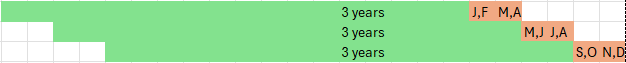

For this setup, val_start in the first fold is fixed at 2024-01-01 00:00:00 and train_end the hour before that (2023-12-31 23:00:00). train_start, val_end and remaining fold values are computed using train_window, predict_horizon and stride.

**Setup 2**



For this setup, val_end in the first fold is fixed at 2024-12-31 23:00:00. train_start, train_end and val_start are computed using train_window and predict_horizon. There is only one fold, so stride has no function.

Write the desired setup number as "split_setup" in the hyper_param_split() function below.

In [3]:
setup = 2

Import models

In [4]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
# Import model library. E.g.:
# from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from Modules.Load_RF_forecast_models import load_rf_models

rf_models = None
if not (dk1_use_precomputed_feature_values and dk2_use_precomputed_feature_values):
    # load_rf_models currently supports only the optional timeout argument.
    rf_models = load_rf_models(user="Christine - laptop")      # set user to "Nikolaj" or "Christine"

# Initialize model:
model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)


In [5]:
from skforecast.exceptions import IgnoredArgumentWarning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message="Raw feature columns are present")
warnings.filterwarnings("ignore", category=UserWarning, message="Some categorized features not in dataset")
warnings.filterwarnings("ignore", category=UserWarning, message="X does not have valid feature names")
warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

Make train and test periods

In [6]:
import pandas as pd
from Modules.Validation2 import _build_validation_folds

price_zone = "DK1"
if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
else:
    train_data = DK2_train
    test_data = DK2_test

dataset = pd.concat([train_data, test_data], ignore_index=True)

folds = _build_validation_folds(
    data=dataset,
    train_window=2*8760+8784,        
    val_window=len(test_data),
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data),         # 168 hours = 1 week
    stride=len(test_data),               # stride between predict_periods              
)

train_start = folds[0]["train_start"]
train_end = folds[0]["train_end"]
num_folds = len(folds)
val_start = folds[0]["val_start"]
val_end = val_start + pd.Timedelta(hours=len(test_data) - 1)
prediction_period = folds[0]["val_end"] - folds[0]["val_start"] + pd.Timedelta(hours=1)

print(f"Fold {folds[0]['fold']} train start: {train_start} - train end: {train_end}")
print(f"Number of folds: {num_folds}")
print(f"Test window start: {val_start} - test window end: {val_end}")
print(f"Prediction period: {prediction_period}")
for fold in range(len(folds)):
    print(f"Fold {folds[fold]['fold']} test start: {folds[fold]['val_start']} - test end: {folds[fold]['val_end']}")

Fold 1 train start: 2022-01-01 00:00:00 - train end: 2024-12-31 23:00:00
Number of folds: 1
Test window start: 2025-01-01 00:00:00 - test window end: 2025-12-31 23:00:00
Prediction period: 365 days 00:00:00
Fold 1 test start: 2025-01-01 00:00:00 - test end: 2025-12-31 23:00:00


c:\Users\Christine\anaconda3\envs\ds809\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Train and test the final model

## Random Forest

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36
Model trained in 50.35s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 293.344

Average MAE across all weeks in all folds: 221.932

Average SMAPE across all weeks in all folds: 53.147


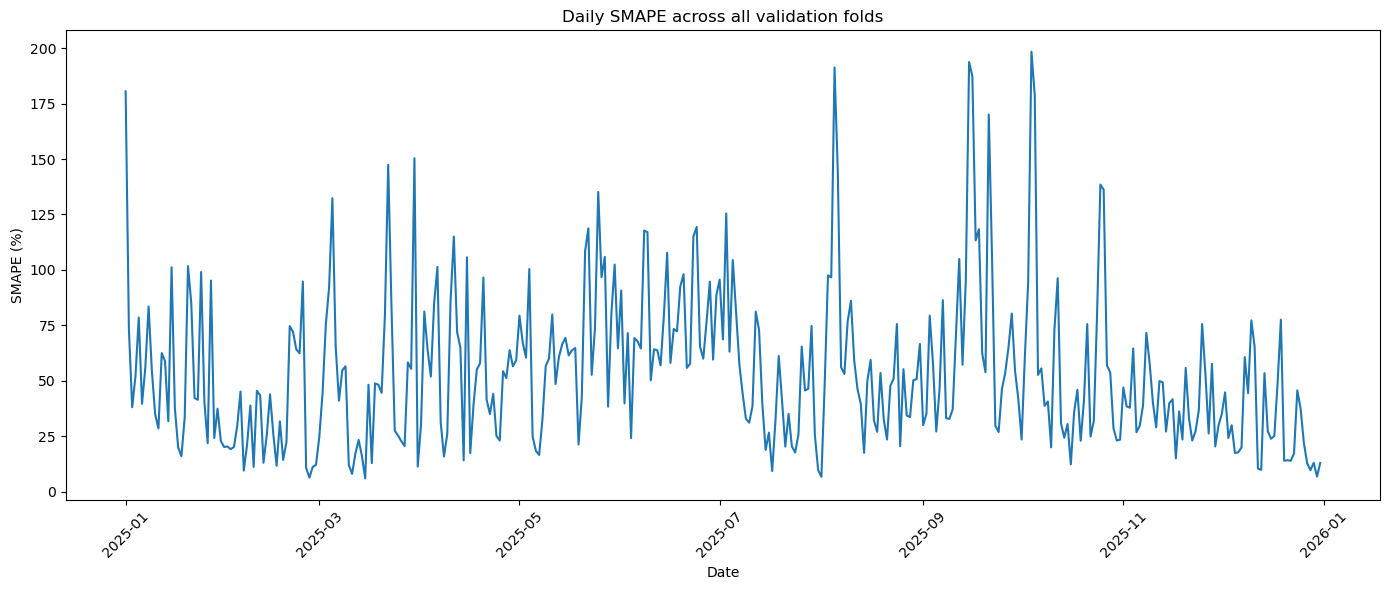

In [7]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from sklearn.ensemble import RandomForestRegressor

# Initialize model:
model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Set price zone and parameters
# ========================
price_zone = "DK1"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    'n_estimators': 200,
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 1
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models = rf_models,
    use_precomputed_feature_values = use_precomputed_feature_values,
    precomputed_feature_predictions = feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "New_Eval")
base_filename = f"{price_zone}_RF_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = f"{base_filename}_{counter}.csv"
    filename = os.path.join(folder, filename)
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_RF_predictions.csv"),
    index=False,
    decimal=","
)

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36
Model trained in 6.12s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 440.095

Average MAE across all weeks in all folds: 373.610

Average SMAPE across all weeks in all folds: 82.171


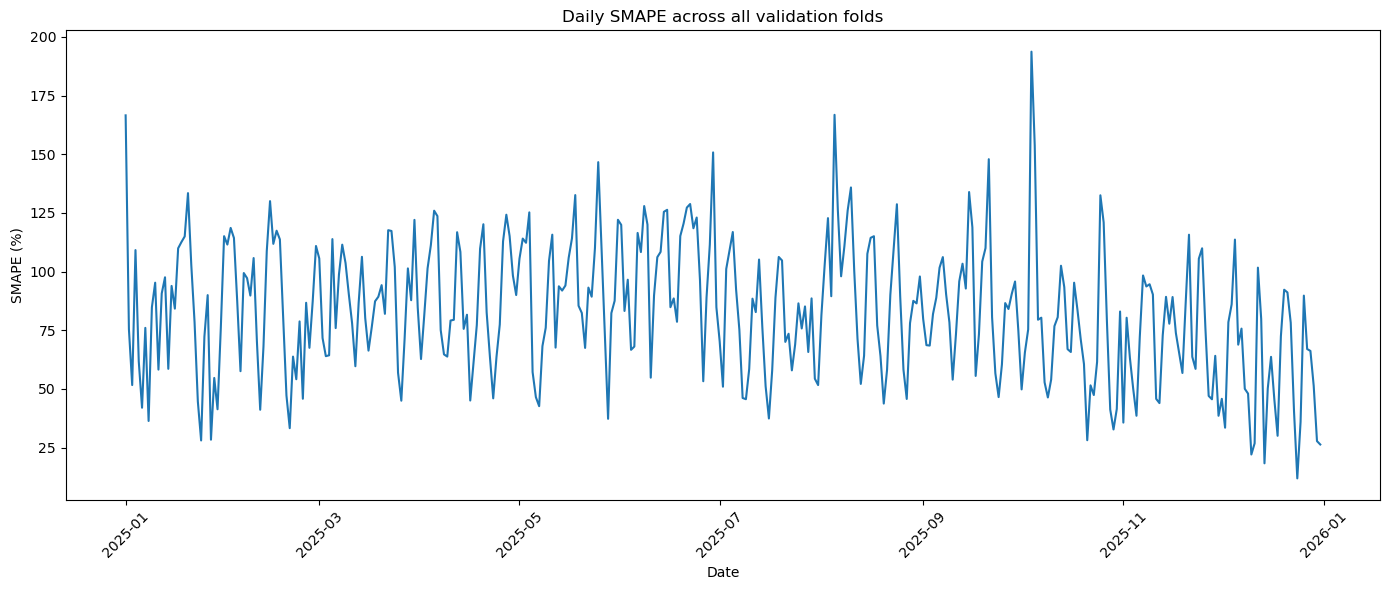

In [8]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from sklearn.ensemble import RandomForestRegressor

# Initialize model:
model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Set price zone and parameters
# ========================
price_zone = "DK2"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    'n_estimators': 50,
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 10
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models = rf_models,
    use_precomputed_feature_values = use_precomputed_feature_values,
    precomputed_feature_predictions = feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "New_Eval")
base_filename = f"{price_zone}_RF_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = f"{base_filename}_{counter}.csv"
    filename = os.path.join(folder, filename)
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_RF_predictions.csv"),
    index=False,
    decimal=","
)

## ARIMA

In [9]:
import itertools
import os
import warnings

import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning

from Modules.Validation2 import _build_validation_folds, smape

warnings.filterwarnings("ignore", category=ConvergenceWarning)


def _prepare_target_series(data, target_col):
    series = (
        data[["Time", target_col]]
        .copy()
        .sort_values("Time")
        .drop_duplicates(subset="Time")
        .set_index("Time")[target_col]
        .astype(float)
    )
    series.index = pd.DatetimeIndex(series.index)
    return series.asfreq("h")


def _fit_arima(train_series, order):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=ConvergenceWarning)
        fitted_model = ARIMA(
            train_series,
            order=order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit()
    return fitted_model


def _build_weekly_and_daily_metrics(actual, predicted, fold_no, week_no):
    evaluation = pd.DataFrame(
        {
            "Time": actual.index,
            "Actual": actual.values,
            "Prediction": predicted.reindex(actual.index).values,
        }
    )
    evaluation["Date"] = evaluation["Time"].dt.floor("D")

    rmse = float(np.sqrt(np.mean((evaluation["Actual"] - evaluation["Prediction"]) ** 2)))
    mae = float(np.mean(np.abs(evaluation["Actual"] - evaluation["Prediction"])))
    smape_value = float(smape(evaluation["Actual"].values, evaluation["Prediction"].values))

    weekly_row = {
        "fold": fold_no,
        "week": week_no,
        "week_start": evaluation["Time"].min(),
        "week_end": evaluation["Time"].max(),
        "weekly_rmse": rmse,
        "weekly_mae": mae,
        "weekly_smape": smape_value,
    }

    daily_rows = []
    for date, day_group in evaluation.groupby("Date"):
        daily_rows.append(
            {
                "Date": date,
                "daily_rmse": float(
                    np.sqrt(np.mean((day_group["Actual"] - day_group["Prediction"]) ** 2))
                ),
                "daily_mae": float(np.mean(np.abs(day_group["Actual"] - day_group["Prediction"]))),
                "daily_smape": float(smape(day_group["Actual"].values, day_group["Prediction"].values)),
                "fold": fold_no,
                "week": week_no,
            }
        )

    return weekly_row, pd.DataFrame(daily_rows)


def run_arima_search(
    *,
    price_zone,
    train_data,
    test_data,
    param_grid,
    output_subfolder,
    base_filename,
    train_window,
    val_window,
    val_start,
    predict_period,
    stride,
):
    dataset = pd.concat([train_data, test_data], ignore_index=True)
    dataset = dataset.sort_values("Time").reset_index(drop=True)
    target_col = dataset.columns[0]

    folds = _build_validation_folds(
        data=dataset,
        train_window=train_window,
        val_window=val_window,
        val_start=val_start,
        predict_period=predict_period,
        stride=stride,
    )

    first_fold = folds[0]
    train_mask = (
        (dataset["Time"] >= first_fold["train_start"])
        & (dataset["Time"] <= first_fold["train_end"])
    )
    train_series = _prepare_target_series(dataset.loc[train_mask], target_col)

    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())
    all_combinations = list(itertools.product(*param_values))
    num_combinations = len(all_combinations)

    max_horizon = int(
        (folds[-1]["val_end"] - first_fold["train_end"]).total_seconds() // 3600
    )
    forecast_index = pd.date_range(
        start=first_fold["train_end"] + pd.Timedelta(hours=1),
        periods=max_horizon,
        freq="h",
    )

    print(f"Total number of combinations to test: {num_combinations}")

    results = []
    for comb_number, combination in enumerate(all_combinations, start=1):
        params = dict(zip(param_names, combination))
        order = params["order"]

        print(f"\nCombination {comb_number}/{num_combinations}: {params}")

        try:
            fitted_model = _fit_arima(train_series, order=order)
            forecast = pd.Series(fitted_model.forecast(steps=max_horizon), index=forecast_index)
        except Exception as exc:
            print(f"Combination {comb_number} failed: {exc}")
            continue

        weekly_results = []
        daily_results = []

        for fold in folds:
            fold_mask = (
                (dataset["Time"] >= fold["val_start"])
                & (dataset["Time"] <= fold["val_end"])
            )
            fold_actual = _prepare_target_series(dataset.loc[fold_mask], target_col)
            fold_pred = forecast.loc[fold["val_start"]:fold["val_end"]]

            if len(fold_actual) != len(fold_pred):
                raise ValueError(
                    f"Forecast length mismatch in fold {fold['fold']}: "
                    f"actual={len(fold_actual)}, predicted={len(fold_pred)}"
                )

            fold_week_rmse = []
            fold_week_mae = []
            fold_week_smape = []

            for week_no, start in enumerate(range(0, len(fold_actual), 168), start=1):
                week_actual = fold_actual.iloc[start:start + 168]
                week_pred = fold_pred.iloc[start:start + 168]

                weekly_row, daily_rows = _build_weekly_and_daily_metrics(
                    actual=week_actual,
                    predicted=week_pred,
                    fold_no=fold["fold"],
                    week_no=week_no,
                )
                weekly_results.append(weekly_row)
                daily_results.append(daily_rows)

                fold_week_rmse.append(weekly_row["weekly_rmse"])
                fold_week_mae.append(weekly_row["weekly_mae"])
                fold_week_smape.append(weekly_row["weekly_smape"])

        weekly_results_df = pd.DataFrame(weekly_results)
        daily_results_df = pd.concat(daily_results, ignore_index=True)
        daily_results_df = daily_results_df.sort_values(["fold", "week", "Date"]).reset_index(drop=True)
        daily_results_df["day_in_week"] = daily_results_df.groupby(["fold", "week"]).cumcount() + 1

        overall_daily_rmse_df = (
            daily_results_df.groupby("Date", as_index=False)["daily_rmse"].mean().sort_values("Date")
        )
        overall_daily_mae_df = (
            daily_results_df.groupby("Date", as_index=False)["daily_mae"].mean().sort_values("Date")
        )
        overall_daily_smape_df = (
            daily_results_df.groupby("Date", as_index=False)["daily_smape"].mean().sort_values("Date")
        )

        avg_smape_by_day = {
            f"avg_smape_day_{day}": daily_results_df.loc[
                daily_results_df["day_in_week"] == day,
                "daily_smape",
            ].mean()
            for day in range(1, 8)
        }

        row = {
            **params,
            "avg_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_weekly_rmse": weekly_results_df["weekly_rmse"].mean(),
            "avg_weekly_mae": weekly_results_df["weekly_mae"].mean(),
            "avg_weekly_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_daily_rmse": overall_daily_rmse_df["daily_rmse"].mean(),
            "avg_daily_mae": overall_daily_mae_df["daily_mae"].mean(),
            "avg_daily_smape": overall_daily_smape_df["daily_smape"].mean(),
            **avg_smape_by_day,
        }
        results.append(row)

    results_df = pd.DataFrame(results).sort_values("avg_smape")

    folder = os.path.join(project_root, "Shallow learners", output_subfolder)
    os.makedirs(folder, exist_ok=True)
    filename = os.path.join(folder, f"{base_filename}.csv")

    counter = 1
    while os.path.exists(filename):
        filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
        counter += 1

    results_df.to_csv(filename, index=False, decimal=",")
    print(f"\nResults saved to: {filename}")

    return results_df, filename


In [10]:
import os
import pandas as pd

price_zone = "DK1"
final_order = (2, 1, 1)

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
else:
    train_data = DK2_train
    test_data = DK2_test

train_series = _prepare_target_series(train_data, train_data.columns[0])
test_series = _prepare_target_series(test_data, test_data.columns[0])

fitted_model = _fit_arima(train_series, final_order)
forecast = pd.Series(
    fitted_model.forecast(steps=len(test_series)),
    index=test_series.index,
)

evaluation = pd.DataFrame(
    {
        "Time": test_series.index,
        "Actual": test_series.values,
        "Prediction": forecast.values,
    }
)
evaluation["Date"] = evaluation["Time"].dt.floor("D")

weekly_rows = []
daily_rows = []
for week_no, start in enumerate(range(0, len(evaluation), 168), start=1):
    week_eval = evaluation.iloc[start:start + 168].copy()

    weekly_rows.append(
        {
            "fold": 1,
            "week": week_no,
            "week_start": week_eval["Time"].min(),
            "week_end": week_eval["Time"].max(),
            "weekly_rmse": float(np.sqrt(np.mean((week_eval["Actual"] - week_eval["Prediction"]) ** 2))),
            "weekly_mae": float(np.mean(np.abs(week_eval["Actual"] - week_eval["Prediction"]))),
            "weekly_smape": float(smape(week_eval["Actual"].values, week_eval["Prediction"].values)),
        }
    )

    for date, day_group in week_eval.groupby("Date"):
        daily_rows.append(
            {
                "fold": 1,
                "week": week_no,
                "Date": date,
                "daily_rmse": float(np.sqrt(np.mean((day_group["Actual"] - day_group["Prediction"]) ** 2))),
                "daily_mae": float(np.mean(np.abs(day_group["Actual"] - day_group["Prediction"]))),
                "daily_smape": float(smape(day_group["Actual"].values, day_group["Prediction"].values)),
            }
        )

weekly_results_df = pd.DataFrame(weekly_rows)
daily_results_df = pd.DataFrame(daily_rows).sort_values(["fold", "week", "Date"]).reset_index(drop=True)
daily_results_df["day_in_week"] = daily_results_df.groupby(["fold", "week"]).cumcount() + 1

overall_daily_rmse_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_rmse"].mean().sort_values("Date")
)
overall_daily_mae_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_mae"].mean().sort_values("Date")
)
overall_daily_smape_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_smape"].mean().sort_values("Date")
)

avg_smape_by_day = {
    f"avg_smape_day_{day}": daily_results_df.loc[
        daily_results_df["day_in_week"] == day,
        "daily_smape",
    ].mean()
    for day in range(1, 8)
}

results_df = pd.DataFrame(
    [
        {
            "order": final_order,
            "avg_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_weekly_rmse": weekly_results_df["weekly_rmse"].mean(),
            "avg_weekly_mae": weekly_results_df["weekly_mae"].mean(),
            "avg_weekly_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_daily_rmse": overall_daily_rmse_df["daily_rmse"].mean(),
            "avg_daily_mae": overall_daily_mae_df["daily_mae"].mean(),
            "avg_daily_smape": overall_daily_smape_df["daily_smape"].mean(),
            **avg_smape_by_day,
        }
    ]
)

folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "New_Eval")
os.makedirs(folder, exist_ok=True)
base_filename = f"{price_zone}_final_ARIMA_results"
filename = os.path.join(folder, f"{base_filename}.csv")

counter = 1
while os.path.exists(filename):
    filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
    counter += 1

results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")

evaluation.to_csv(
    os.path.join(folder, f"{price_zone}_ARIMA_predictions.csv"),
    index=False,
    decimal=","
)


Results saved to: c:\Users\Christine\Documents\Python\Speciale_Kode\Shallow learners\New_Eval\DK1_final_ARIMA_results.csv


In [11]:
import os
import pandas as pd

price_zone = "DK2"
final_order = (2, 1, 1)

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
else:
    train_data = DK2_train
    test_data = DK2_test

train_series = _prepare_target_series(train_data, train_data.columns[0])
test_series = _prepare_target_series(test_data, test_data.columns[0])

fitted_model = _fit_arima(train_series, final_order)
forecast = pd.Series(
    fitted_model.forecast(steps=len(test_series)),
    index=test_series.index,
)

evaluation = pd.DataFrame(
    {
        "Time": test_series.index,
        "Actual": test_series.values,
        "Prediction": forecast.values,
    }
)
evaluation["Date"] = evaluation["Time"].dt.floor("D")

weekly_rows = []
daily_rows = []
for week_no, start in enumerate(range(0, len(evaluation), 168), start=1):
    week_eval = evaluation.iloc[start:start + 168].copy()

    weekly_rows.append(
        {
            "fold": 1,
            "week": week_no,
            "week_start": week_eval["Time"].min(),
            "week_end": week_eval["Time"].max(),
            "weekly_rmse": float(np.sqrt(np.mean((week_eval["Actual"] - week_eval["Prediction"]) ** 2))),
            "weekly_mae": float(np.mean(np.abs(week_eval["Actual"] - week_eval["Prediction"]))),
            "weekly_smape": float(smape(week_eval["Actual"].values, week_eval["Prediction"].values)),
        }
    )

    for date, day_group in week_eval.groupby("Date"):
        daily_rows.append(
            {
                "fold": 1,
                "week": week_no,
                "Date": date,
                "daily_rmse": float(np.sqrt(np.mean((day_group["Actual"] - day_group["Prediction"]) ** 2))),
                "daily_mae": float(np.mean(np.abs(day_group["Actual"] - day_group["Prediction"]))),
                "daily_smape": float(smape(day_group["Actual"].values, day_group["Prediction"].values)),
            }
        )

weekly_results_df = pd.DataFrame(weekly_rows)
daily_results_df = pd.DataFrame(daily_rows).sort_values(["fold", "week", "Date"]).reset_index(drop=True)
daily_results_df["day_in_week"] = daily_results_df.groupby(["fold", "week"]).cumcount() + 1

overall_daily_rmse_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_rmse"].mean().sort_values("Date")
)
overall_daily_mae_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_mae"].mean().sort_values("Date")
)
overall_daily_smape_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_smape"].mean().sort_values("Date")
)

avg_smape_by_day = {
    f"avg_smape_day_{day}": daily_results_df.loc[
        daily_results_df["day_in_week"] == day,
        "daily_smape",
    ].mean()
    for day in range(1, 8)
}

results_df = pd.DataFrame(
    [
        {
            "order": final_order,
            "avg_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_weekly_rmse": weekly_results_df["weekly_rmse"].mean(),
            "avg_weekly_mae": weekly_results_df["weekly_mae"].mean(),
            "avg_weekly_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_daily_rmse": overall_daily_rmse_df["daily_rmse"].mean(),
            "avg_daily_mae": overall_daily_mae_df["daily_mae"].mean(),
            "avg_daily_smape": overall_daily_smape_df["daily_smape"].mean(),
            **avg_smape_by_day,
        }
    ]
)

folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "New_Eval")
os.makedirs(folder, exist_ok=True)
base_filename = f"{price_zone}_final_ARIMA_results"
filename = os.path.join(folder, f"{base_filename}.csv")

counter = 1
while os.path.exists(filename):
    filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
    counter += 1

results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")

evaluation.to_csv(
    os.path.join(folder, f"{price_zone}_ARIMA_predictions.csv"),
    index=False,
    decimal=","
)


Results saved to: c:\Users\Christine\Documents\Python\Speciale_Kode\Shallow learners\New_Eval\DK2_final_ARIMA_results.csv


## ARIMAX

In [13]:
import itertools
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning

from Modules.Load_RF_forecast_models import load_rf_models
from Modules.Validation2 import _build_validation_folds, smape
import Modules.week_predictions as wp

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Exogenous feature RF models used by the production feature-forecasting pipeline.
rf_models = load_rf_models(user="Christine - laptop")

# Cache exogenous forecasts across parameter combinations.
_ARIMAX_EXOG_CACHE = {}


def _load_feature_predictions_for_zone(zone):
    prediction_path = Path(project_root) / "Data" / f"feature_predictions_{zone}_2024-2025.csv"
    if not prediction_path.exists():
        print(f"No precomputed forecasts found at: {prediction_path}")
        return None

    predictions = pd.read_csv(
        prediction_path,
        sep=";",
        decimal=".",
        parse_dates=["Time"],
        dayfirst=True,
    )
    predictions = predictions.loc[:, ~predictions.columns.duplicated()].copy()
    if "DKZone" in predictions.columns:
        predictions = predictions.loc[predictions["DKZone"] == zone].copy()

    print(f"Loaded {len(predictions)} precomputed forecast rows for zone {zone}.")
    return predictions


def _prepare_target_series(data, target_col):
    series = (
        data[["Time", target_col]]
        .copy()
        .sort_values("Time")
        .drop_duplicates(subset="Time")
        .set_index("Time")[target_col]
        .astype(float)
    )
    series.index = pd.DatetimeIndex(series.index)
    return series.asfreq("h")


def _get_feature_columns(dataset, target_col):
    feature_columns = []
    for col in [c for c in dataset.columns if c not in {"Time", target_col}]:
        base_feature, lag_hours = wp._parse_lag_feature(col)
        if lag_hours is not None:
            resolved_base = wp._resolve_base_feature(base_feature, target_col)
            if resolved_base == target_col:
                continue
        feature_columns.append(col)
    return feature_columns


def _clean_exog(exog_df):
    exog = exog_df.copy()
    exog = exog.replace([np.inf, -np.inf], np.nan)
    exog = exog.ffill().bfill().fillna(0.0)
    return exog.astype(float)


def _forecast_exog_for_period(
    dataset,
    period_start,
    period_end,
    feature_columns,
    dk_zone,
    rf_models,
    forecast_horizon=168,
    use_precomputed_feature_values=False,
    precomputed_feature_predictions=None,
    weather_noise: bool = False,        
    rng: np.random.Generator | None = None,
):
    data = dataset.copy().sort_values("Time").reset_index(drop=True)
    target_col = data.columns[0]
    cache_key = (
        str(data["Time"].min()),
        str(data["Time"].max()),
        len(data),
        str(period_start),
        str(period_end),
        tuple(feature_columns),
        dk_zone,
        int(forecast_horizon),
        bool(rf_models),
        bool(use_precomputed_feature_values),
        bool(precomputed_feature_predictions is not None),
        bool(weather_noise),  
    )

    if cache_key in _ARIMAX_EXOG_CACHE:
        print("  Using cached exogenous forecast...", flush=True)
        return _ARIMAX_EXOG_CACHE[cache_key].copy()

    horizon_mask = (data["Time"] >= period_start) & (data["Time"] <= period_end)
    horizon_hours = data.loc[horizon_mask, "Time"].tolist()
    if not horizon_hours:
        raise ValueError("No timestamps found in selected period.")

    simulated_history = data.loc[data["Time"] < period_start].copy().reset_index(drop=True)
    if simulated_history.empty:
        raise ValueError("Need historical rows before period_start to construct lags.")

    precomputed_predictions = None
    if use_precomputed_feature_values and precomputed_feature_predictions is not None:
        precomputed_predictions = precomputed_feature_predictions.copy()
        precomputed_predictions = precomputed_predictions.loc[:, ~precomputed_predictions.columns.duplicated()].copy()
        if "DKZone" in precomputed_predictions.columns:
            precomputed_predictions = precomputed_predictions.loc[precomputed_predictions["DKZone"] == dk_zone].copy()
        precomputed_predictions["Time"] = pd.to_datetime(precomputed_predictions["Time"], dayfirst=True)

    present_forecast_features = [
        feat for feat in wp.FORECASTABLE_FEATURES if feat in data.columns and feat != target_col
    ]
    non_rf_features = [
        feat
        for feat in present_forecast_features
        if wp.FORECAST_METHODS[dk_zone].get(feat) in {"lag24", "lag168", "last_known_value", "skforecast"}
    ]
    rf_features = [
        feat for feat in present_forecast_features if wp.FORECAST_METHODS[dk_zone].get(feat) == "rf"
    ]

    block_frames = []
    block_start_idx = 0

    while block_start_idx < len(horizon_hours):
        block_hours = horizon_hours[block_start_idx:block_start_idx + forecast_horizon]
        block_true = data.loc[data["Time"].isin(block_hours)].copy().reset_index(drop=True)
        block_df = pd.DataFrame({"Time": block_true["Time"]})

        for col in present_forecast_features:
            if col in block_true.columns:
                block_df[col] = block_true[col].to_numpy()

        if precomputed_predictions is not None:
            block_precomputed = precomputed_predictions.loc[
                precomputed_predictions["Time"].isin(block_hours)
            ].sort_values("Time")
            if len(block_precomputed) == len(block_df):
                for col in present_forecast_features:
                    if col in block_precomputed.columns:
                        block_df[col] = block_precomputed[col].to_numpy()

        for col in wp.KNOWN_FUTURE_FEATURES + wp.WEATHER_FEATURES + wp.CAPACITY_FEATURES:
            if col in block_true.columns and col not in block_df.columns:
                block_df[col] = block_true[col].to_numpy()

        if weather_noise and rng is not None:
            from Modules.week_predictions_noise import _apply_weather_forecast_noise
            block_df = _apply_weather_forecast_noise(block_df, rng=rng)

        print("  Forecasting non-RF features...", flush=True)
        for feature_name in non_rf_features:
            if (
                use_precomputed_feature_values
                and feature_name in block_df.columns
                and block_df[feature_name].notna().all()
            ):
                continue

            method = wp.FORECAST_METHODS[dk_zone][feature_name]
            if method == "lag24":
                block_df[feature_name] = wp._forecast_lag_feature_for_week(
                    simulated_history, block_df, feature_name, 24
                )
            elif method == "lag168":
                block_df[feature_name] = wp._forecast_lag_feature_for_week(
                    simulated_history, block_df, feature_name, 168
                )
            elif method == "last_known_value":
                block_df[feature_name] = wp._forecast_last_known_value_for_week(
                    simulated_history, feature_name, len(block_df)
                )
            elif method == "skforecast":
                block_df[feature_name] = wp._forecast_skforecast_feature_for_week(
                    simulated_history, block_df, feature_name, offset=168, n_offsets=3, agg_func=np.mean
                )
            else:
                raise ValueError(f"Unsupported forecast method '{method}' for {feature_name}.")

        print("  Forecasting RF features...", flush=True)
        feature_no = 0
        for feature_name in rf_features:
            feature_no += 1
            print(f"  - Forecasting {feature_no}/{len(rf_features)}: {feature_name} ", flush=True)
            if (
                use_precomputed_feature_values
                and feature_name in block_df.columns
                and block_df[feature_name].notna().all()
            ):
                continue
            if rf_models is None or not rf_models:
                raise ValueError("rf_models are required to forecast RF-based exogenous features.")
            block_df[feature_name] = wp._forecast_rf_feature_for_week(
                simulated_history, block_df, feature_name, dk_zone, rf_models
            )

        for col in feature_columns:
            if col in block_df.columns:
                continue
            if col in block_true.columns:
                block_df[col] = block_true[col].to_numpy()
                continue

            base_feature, lag_hours = wp._parse_lag_feature(col)
            if lag_hours is None:
                block_df[col] = np.nan
                continue

            resolved_base = wp._resolve_base_feature(base_feature, target_col)
            if resolved_base == target_col:
                block_df[col] = np.nan
                continue

            print("  Computing lag features...")
            lag_vals = [
                wp._value_from_lag(simulated_history, block_df, resolved_base, ts, lag_hours)
                for ts in block_df["Time"]
            ]
            block_df[col] = lag_vals

        block_exog = block_df[["Time"] + feature_columns].copy()
        block_frames.append(block_exog)

        history_append = block_df.copy()
        for col in data.columns:
            if col not in history_append.columns:
                history_append[col] = np.nan
        history_append = history_append[data.columns]
        simulated_history = pd.concat([simulated_history, history_append], ignore_index=True)

        block_start_idx += forecast_horizon

    exog_forecast = pd.concat(block_frames, ignore_index=True)
    exog_forecast = exog_forecast.drop_duplicates(subset="Time").sort_values("Time")
    exog_forecast = exog_forecast.set_index("Time")[feature_columns]
    cleaned_exog_forecast = _clean_exog(exog_forecast)
    _ARIMAX_EXOG_CACHE[cache_key] = cleaned_exog_forecast.copy()
    return cleaned_exog_forecast


def _fit_arimax(train_series, train_exog, order):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=ConvergenceWarning)
        fitted_model = ARIMA(
            train_series,
            exog=_clean_exog(train_exog),
            order=order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit()
    return fitted_model


def _build_weekly_and_daily_metrics(actual, predicted, fold_no, week_no):
    evaluation = pd.DataFrame(
        {
            "Time": actual.index,
            "Actual": actual.values,
            "Prediction": predicted.reindex(actual.index).values,
        }
    )
    evaluation["Date"] = evaluation["Time"].dt.floor("D")

    rmse = float(np.sqrt(np.mean((evaluation["Actual"] - evaluation["Prediction"]) ** 2)))
    mae = float(np.mean(np.abs(evaluation["Actual"] - evaluation["Prediction"])))
    smape_value = float(smape(evaluation["Actual"].values, evaluation["Prediction"].values))

    weekly_row = {
        "fold": fold_no,
        "week": week_no,
        "week_start": evaluation["Time"].min(),
        "week_end": evaluation["Time"].max(),
        "weekly_rmse": rmse,
        "weekly_mae": mae,
        "weekly_smape": smape_value,
    }

    daily_rows = []
    for date, day_group in evaluation.groupby("Date"):
        daily_rows.append(
            {
                "Date": date,
                "daily_rmse": float(
                    np.sqrt(np.mean((day_group["Actual"] - day_group["Prediction"]) ** 2))
                ),
                "daily_mae": float(np.mean(np.abs(day_group["Actual"] - day_group["Prediction"]))),
                "daily_smape": float(smape(day_group["Actual"].values, day_group["Prediction"].values)),
                "fold": fold_no,
                "week": week_no,
            }
        )

    return weekly_row, pd.DataFrame(daily_rows)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\Christine\_netrc.
wandb: Downloading large artifact 'rf_OffshoreWindPower_DK1:latest', 1817.80MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:01.2 (1531.4MB/s)


✓ Loaded RF model for OffshoreWindPower_DK1 from C:\Users\Christine\Documents\Python\Personlig\OffshoreWindPower_DK1


wandb: Downloading large artifact 'rf_OffshoreWindPower_DK2:latest', 1809.79MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.4 (4628.6MB/s)


✓ Loaded RF model for OffshoreWindPower_DK2 from C:\Users\Christine\Documents\Python\Personlig\OffshoreWindPower_DK2


wandb: Downloading large artifact 'rf_OnshoreWindPower_DK1:latest', 1817.91MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.3 (5284.6MB/s)


✓ Loaded RF model for OnshoreWindPower_DK1 from C:\Users\Christine\Documents\Python\Personlig\OnshoreWindPower_DK1


wandb: Downloading large artifact 'rf_OnshoreWindPower_DK2:latest', 1815.11MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.3 (5276.5MB/s)


✓ Loaded RF model for OnshoreWindPower_DK2 from C:\Users\Christine\Documents\Python\Personlig\OnshoreWindPower_DK2


wandb: Downloading large artifact 'rf_SolarPower_DK1:latest', 1666.36MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.3 (4844.1MB/s)


✓ Loaded RF model for SolarPower_DK1 from C:\Users\Christine\Documents\Python\Personlig\SolarPower_DK1


wandb: Downloading large artifact 'rf_SolarPower_DK2:latest', 1580.46MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.3 (4818.5MB/s)


✓ Loaded RF model for SolarPower_DK2 from C:\Users\Christine\Documents\Python\Personlig\SolarPower_DK2


wandb: Downloading large artifact 'rf_TotalProduction_DK1:latest', 1817.61MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.4 (4476.9MB/s)


✓ Loaded RF model for TotalProduction_DK1 from C:\Users\Christine\Documents\Python\Personlig\TotalProduction_DK1


wandb: Downloading large artifact 'rf_TotalProduction_DK2:latest', 1817.23MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.3 (5540.3MB/s)


✓ Loaded RF model for TotalProduction_DK2 from C:\Users\Christine\Documents\Python\Personlig\TotalProduction_DK2

✓ Successfully loaded 8 RF models


In [14]:
exo_features = None     # Use auto-detected features based on dataset columns and lag parsing logic.

dk1_precomputed_feature_predictions = _load_feature_predictions_for_zone("DK1")
use_dk1_precomputed_feature_values = dk1_precomputed_feature_predictions is not None

exo_features = None     # Use auto-detected features based on dataset columns and lag parsing logic.

dk2_precomputed_feature_predictions = _load_feature_predictions_for_zone("DK2")
use_dk2_precomputed_feature_values = dk2_precomputed_feature_predictions is not None


Loaded 17544 precomputed forecast rows for zone DK1.
Loaded 17544 precomputed forecast rows for zone DK2.


In [15]:
import os
import math
import numpy as np
import pandas as pd
from pathlib import Path
from time import time

# Set price zone and final ARIMAX order
price_zone = "DK1"
final_order = (2, 1, 0)

if "folds" not in globals() or len(folds) == 0:
    raise ValueError("Run the previous 'Make train and test periods' cell first so 'folds' is available.")

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    precomputed_feature_predictions = (
        dk1_precomputed_feature_predictions
        if "dk1_precomputed_feature_predictions" in globals()
        else _load_feature_predictions_for_zone("DK1")
    )
else:
    train_data = DK2_train
    test_data = DK2_test
    precomputed_feature_predictions = (
        dk2_precomputed_feature_predictions
        if "dk2_precomputed_feature_predictions" in globals()
        else _load_feature_predictions_for_zone("DK2")
    )

use_precomputed_feature_values = precomputed_feature_predictions is not None
print(f"Use precomputed feature values: {use_precomputed_feature_values}")

start_time = time()
dataset = pd.concat([train_data, test_data], ignore_index=True)
dataset = dataset.sort_values("Time").reset_index(drop=True)
dataset.attrs["dk_zone"] = price_zone
target_col = dataset.columns[0]
feature_columns = _get_feature_columns(dataset, target_col)

# Train once using the train window from the first fold.
first_fold = folds[0]
train_mask = (
    (dataset["Time"] >= first_fold["train_start"]) &
    (dataset["Time"] <= first_fold["train_end"])
)
fold_train = dataset.loc[train_mask].copy()

if fold_train.empty:
    raise ValueError("Training window from the first fold is empty. Check fold setup.")

train_series = _prepare_target_series(fold_train, target_col)
train_exog = _clean_exog(
    fold_train[["Time"] + feature_columns].set_index("Time")[feature_columns]
)

print("Training model once on first fold train window... ({:.2f} sec)".format(time() - start_time))
fitted_model = _fit_arimax(train_series, train_exog, final_order)

# Rolling state model: updated with true observations after each fold, no retraining.
rolling_model = fitted_model
print("Model trained once. Forecasting each test fold with state updates and no retraining...")

weekly_rows = []
daily_rows = []
all_fold_evaluations = []
all_fold_exog = []
all_fold_forecasts = []

_ARIMAX_EXOG_CACHE.clear()
rng = np.random.default_rng(42)

global_week_counter = 0
for fold_idx, fold in enumerate(folds, start=1):
    print(
        f"Fold {fold_idx}/{len(folds)}: "
        f"{fold['val_start']} -> {fold['val_end']}"
    )

    # Exogenous forecast starts from true historical data before each fold start.
    fold_exog = _forecast_exog_for_period(
        dataset=dataset,
        period_start=fold["val_start"],
        period_end=fold["val_end"],
        feature_columns=feature_columns,
        dk_zone=price_zone,
        rf_models=rf_models,
        forecast_horizon=168,
        use_precomputed_feature_values=use_precomputed_feature_values,
        precomputed_feature_predictions=precomputed_feature_predictions,
        weather_noise=False, 
        rng=None,              
    )
    fold_exog_clean = _clean_exog(fold_exog)

    fold_forecast = pd.Series(
        rolling_model.get_forecast(
            steps=len(fold_exog_clean),
            exog=fold_exog_clean,
        ).predicted_mean,
        index=fold_exog_clean.index,
    )

    fold_actual_mask = (
        (dataset["Time"] >= fold["val_start"]) &
        (dataset["Time"] <= fold["val_end"])
    )
    fold_actual = _prepare_target_series(dataset.loc[fold_actual_mask], target_col)

    if len(fold_actual) != len(fold_forecast):
        raise ValueError(
            f"Forecast length mismatch in fold {fold['fold']}: "
            f"actual={len(fold_actual)}, predicted={len(fold_forecast)}"
        )

    # Update state with true observations from this fold before forecasting next fold.
    aligned_exog_for_update = fold_exog_clean.reindex(fold_actual.index)
    if aligned_exog_for_update.isna().any().any():
        raise ValueError(
            f"Exogenous alignment mismatch in fold {fold['fold']} when updating model state."
        )
    rolling_model = rolling_model.append(
        endog=fold_actual,
        exog=aligned_exog_for_update,
        refit=False,
    )

    fold_eval = pd.DataFrame(
        {
            "Time": fold_actual.index,
            "Actual": fold_actual.values,
            "Prediction": fold_forecast.reindex(fold_actual.index).values,
        }
    )
    fold_eval["Date"] = fold_eval["Time"].dt.floor("D")
    fold_eval["week"] = (pd.RangeIndex(len(fold_eval)) // 168) + 1 + global_week_counter

    all_fold_evaluations.append(fold_eval)
    all_fold_exog.append(fold_exog_clean)
    all_fold_forecasts.append(fold_forecast)

    for week_no, start in enumerate(range(0, len(fold_eval), 168), start=1):
        week_eval = fold_eval.iloc[start:start + 168].copy()

        weekly_rows.append(
            {
                "fold": fold["fold"],
                "week": week_no,
                "week_start": week_eval["Time"].min(),
                "week_end": week_eval["Time"].max(),
                "weekly_rmse": float(np.sqrt(np.mean((week_eval["Actual"] - week_eval["Prediction"]) ** 2))),
                "weekly_mae": float(np.mean(np.abs(week_eval["Actual"] - week_eval["Prediction"]))),
                "weekly_smape": float(smape(week_eval["Actual"].values, week_eval["Prediction"].values)),
            }
        )

        for date, day_group in week_eval.groupby("Date"):
            daily_rows.append(
                {
                    "fold": fold["fold"],
                    "week": week_no,
                    "Date": date,
                    "daily_rmse": float(np.sqrt(np.mean((day_group["Actual"] - day_group["Prediction"]) ** 2))),
                    "daily_mae": float(np.mean(np.abs(day_group["Actual"] - day_group["Prediction"]))),
                    "daily_smape": float(smape(day_group["Actual"].values, day_group["Prediction"].values)),
                }
            )

    global_week_counter += int(math.ceil(len(fold_eval) / 168))

if len(all_fold_evaluations) == 0:
    raise ValueError("No fold evaluations were created.")

evaluation = pd.concat(all_fold_evaluations, ignore_index=True)
weekly_results_df = pd.DataFrame(weekly_rows)
daily_results_df = pd.DataFrame(daily_rows).sort_values(["fold", "week", "Date"]).reset_index(drop=True)
daily_results_df["day_in_week"] = daily_results_df.groupby(["fold", "week"]).cumcount() + 1

overall_daily_rmse_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_rmse"].mean().sort_values("Date")
)
overall_daily_mae_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_mae"].mean().sort_values("Date")
)
overall_daily_smape_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_smape"].mean().sort_values("Date")
)

avg_smape_by_day = {
    f"avg_smape_day_{day}": daily_results_df.loc[
        daily_results_df["day_in_week"] == day,
        "daily_smape",
    ].mean()
    for day in range(1, 8)
}

results_df = pd.DataFrame(
    [
        {
            "order": final_order,
            "avg_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_weekly_rmse": weekly_results_df["weekly_rmse"].mean(),
            "avg_weekly_mae": weekly_results_df["weekly_mae"].mean(),
            "avg_weekly_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_daily_rmse": overall_daily_rmse_df["daily_rmse"].mean(),
            "avg_daily_mae": overall_daily_mae_df["daily_mae"].mean(),
            "avg_daily_smape": overall_daily_smape_df["daily_smape"].mean(),
            **avg_smape_by_day,
        }
    ]
)

notebook_folder = Path(project_root) / "Shallow learners" / "Final_eval" 
notebook_folder.mkdir(parents=True, exist_ok=True)

base_filename = f"{price_zone}_final_ARIMAX_results"
filename = notebook_folder / f"{base_filename}.csv"

counter = 1
while filename.exists():
    filename = notebook_folder / f"{base_filename}_{counter}.csv"
    counter += 1

results_df.to_csv(filename, index=False, decimal=",")
print(f"\nResults saved to: {filename}")

# Save final-model predictions in the notebook folder.
predictions_export_df = evaluation[["Time", "Prediction", "Actual", "week", "Date"]].copy()
predictions_export_df = predictions_export_df.rename(columns={"Actual": "DKPrice"})
predictions_export_df["Time"] = pd.to_datetime(predictions_export_df["Time"]).dt.strftime("%Y-%m-%d %H:%M:%S")
predictions_export_df["Date"] = pd.to_datetime(predictions_export_df["Date"]).dt.strftime("%Y-%m-%d")

pred_base_filename = f"{price_zone}_ARIMAX_predictions"
pred_filename = notebook_folder / f"{pred_base_filename}.csv"
pred_counter = 1
while pred_filename.exists():
    pred_filename = notebook_folder / f"{pred_base_filename}_{pred_counter}.csv"
    pred_counter += 1

predictions_export_df.to_csv(pred_filename, index=False)
print(f"Predictions saved to: {pred_filename}")

combined_test_exog = pd.concat(all_fold_exog).sort_index()
combined_test_forecast = pd.concat(all_fold_forecasts).sort_index()

# Keep objects for SHAP/explainability cell
arimax_final_bundle = {
    "model": fitted_model,
    "price_zone": price_zone,
    "target_col": target_col,
    "feature_columns": feature_columns,
    "train_exog": train_exog,
    "test_exog_forecast": _clean_exog(combined_test_exog),
    "train_fitted": pd.Series(fitted_model.fittedvalues, index=train_series.index),
    "test_forecast": combined_test_forecast,
}

print("Done: model was trained once and evaluated across all folds without retraining, with state updates between folds.")

Use precomputed feature values: True
Training model once on first fold train window... (0.28 sec)
Model trained once. Forecasting each test fold with state updates and no retraining...
Fold 1/1: 2025-01-01 00:00:00 -> 2025-12-31 23:00:00
  Forecasting non-RF features...
  Forecasting RF features...
  - Forecasting 1/4: OffshoreWindPower 
  - Forecasting 2/4: OnshoreWindPower 
  - Forecasting 3/4: SolarPower 
  - Forecasting 4/4: TotalProduction 
  Forecasting non-RF features...
  Forecasting RF features...
  - Forecasting 1/4: OffshoreWindPower 
  - Forecasting 2/4: OnshoreWindPower 
  - Forecasting 3/4: SolarPower 
  - Forecasting 4/4: TotalProduction 
  Forecasting non-RF features...
  Forecasting RF features...
  - Forecasting 1/4: OffshoreWindPower 
  - Forecasting 2/4: OnshoreWindPower 
  - Forecasting 3/4: SolarPower 
  - Forecasting 4/4: TotalProduction 
  Forecasting non-RF features...
  Forecasting RF features...
  - Forecasting 1/4: OffshoreWindPower 
  - Forecasting 2/4: Ons

In [16]:
import os
import math
import numpy as np
import pandas as pd
from pathlib import Path
from time import time

# Set price zone and final ARIMAX order
price_zone = "DK2"
final_order = (1, 1, 0)

if "folds" not in globals() or len(folds) == 0:
    raise ValueError("Run the previous 'Make train and test periods' cell first so 'folds' is available.")

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    precomputed_feature_predictions = (
        dk1_precomputed_feature_predictions
        if "dk1_precomputed_feature_predictions" in globals()
        else _load_feature_predictions_for_zone("DK1")
    )
else:
    train_data = DK2_train
    test_data = DK2_test
    precomputed_feature_predictions = (
        dk2_precomputed_feature_predictions
        if "dk2_precomputed_feature_predictions" in globals()
        else _load_feature_predictions_for_zone("DK2")
    )

use_precomputed_feature_values = precomputed_feature_predictions is not None
print(f"Use precomputed feature values: {use_precomputed_feature_values}")

start_time = time()
dataset = pd.concat([train_data, test_data], ignore_index=True)
dataset = dataset.sort_values("Time").reset_index(drop=True)
dataset.attrs["dk_zone"] = price_zone
target_col = dataset.columns[0]
feature_columns = _get_feature_columns(dataset, target_col)

# Train once using the train window from the first fold.
first_fold = folds[0]
train_mask = (
    (dataset["Time"] >= first_fold["train_start"]) &
    (dataset["Time"] <= first_fold["train_end"])
)
fold_train = dataset.loc[train_mask].copy()

if fold_train.empty:
    raise ValueError("Training window from the first fold is empty. Check fold setup.")

train_series = _prepare_target_series(fold_train, target_col)
train_exog = _clean_exog(
    fold_train[["Time"] + feature_columns].set_index("Time")[feature_columns]
)

print("Training model once on first fold train window... ({:.2f} sec)".format(time() - start_time))
fitted_model = _fit_arimax(train_series, train_exog, final_order)

# Rolling state model: updated with true observations after each fold, no retraining.
rolling_model = fitted_model
print("Model trained once. Forecasting each test fold with state updates and no retraining...")

weekly_rows = []
daily_rows = []
all_fold_evaluations = []
all_fold_exog = []
all_fold_forecasts = []

_ARIMAX_EXOG_CACHE.clear()
rng = np.random.default_rng(42)

global_week_counter = 0
for fold_idx, fold in enumerate(folds, start=1):
    print(
        f"Fold {fold_idx}/{len(folds)}: "
        f"{fold['val_start']} -> {fold['val_end']}"
    )

    # Exogenous forecast starts from true historical data before each fold start.
    fold_exog = _forecast_exog_for_period(
        dataset=dataset,
        period_start=fold["val_start"],
        period_end=fold["val_end"],
        feature_columns=feature_columns,
        dk_zone=price_zone,
        rf_models=rf_models,
        forecast_horizon=168,
        use_precomputed_feature_values=use_precomputed_feature_values,
        precomputed_feature_predictions=precomputed_feature_predictions,
        weather_noise=False, 
        rng=None,              
    )
    fold_exog_clean = _clean_exog(fold_exog)

    fold_forecast = pd.Series(
        rolling_model.get_forecast(
            steps=len(fold_exog_clean),
            exog=fold_exog_clean,
        ).predicted_mean,
        index=fold_exog_clean.index,
    )

    fold_actual_mask = (
        (dataset["Time"] >= fold["val_start"]) &
        (dataset["Time"] <= fold["val_end"])
    )
    fold_actual = _prepare_target_series(dataset.loc[fold_actual_mask], target_col)

    if len(fold_actual) != len(fold_forecast):
        raise ValueError(
            f"Forecast length mismatch in fold {fold['fold']}: "
            f"actual={len(fold_actual)}, predicted={len(fold_forecast)}"
        )

    # Update state with true observations from this fold before forecasting next fold.
    aligned_exog_for_update = fold_exog_clean.reindex(fold_actual.index)
    if aligned_exog_for_update.isna().any().any():
        raise ValueError(
            f"Exogenous alignment mismatch in fold {fold['fold']} when updating model state."
        )
    rolling_model = rolling_model.append(
        endog=fold_actual,
        exog=aligned_exog_for_update,
        refit=False,
    )

    fold_eval = pd.DataFrame(
        {
            "Time": fold_actual.index,
            "Actual": fold_actual.values,
            "Prediction": fold_forecast.reindex(fold_actual.index).values,
        }
    )
    fold_eval["Date"] = fold_eval["Time"].dt.floor("D")
    fold_eval["week"] = (pd.RangeIndex(len(fold_eval)) // 168) + 1 + global_week_counter

    all_fold_evaluations.append(fold_eval)
    all_fold_exog.append(fold_exog_clean)
    all_fold_forecasts.append(fold_forecast)

    for week_no, start in enumerate(range(0, len(fold_eval), 168), start=1):
        week_eval = fold_eval.iloc[start:start + 168].copy()

        weekly_rows.append(
            {
                "fold": fold["fold"],
                "week": week_no,
                "week_start": week_eval["Time"].min(),
                "week_end": week_eval["Time"].max(),
                "weekly_rmse": float(np.sqrt(np.mean((week_eval["Actual"] - week_eval["Prediction"]) ** 2))),
                "weekly_mae": float(np.mean(np.abs(week_eval["Actual"] - week_eval["Prediction"]))),
                "weekly_smape": float(smape(week_eval["Actual"].values, week_eval["Prediction"].values)),
            }
        )

        for date, day_group in week_eval.groupby("Date"):
            daily_rows.append(
                {
                    "fold": fold["fold"],
                    "week": week_no,
                    "Date": date,
                    "daily_rmse": float(np.sqrt(np.mean((day_group["Actual"] - day_group["Prediction"]) ** 2))),
                    "daily_mae": float(np.mean(np.abs(day_group["Actual"] - day_group["Prediction"]))),
                    "daily_smape": float(smape(day_group["Actual"].values, day_group["Prediction"].values)),
                }
            )

    global_week_counter += int(math.ceil(len(fold_eval) / 168))

if len(all_fold_evaluations) == 0:
    raise ValueError("No fold evaluations were created.")

evaluation = pd.concat(all_fold_evaluations, ignore_index=True)
weekly_results_df = pd.DataFrame(weekly_rows)
daily_results_df = pd.DataFrame(daily_rows).sort_values(["fold", "week", "Date"]).reset_index(drop=True)
daily_results_df["day_in_week"] = daily_results_df.groupby(["fold", "week"]).cumcount() + 1

overall_daily_rmse_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_rmse"].mean().sort_values("Date")
)
overall_daily_mae_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_mae"].mean().sort_values("Date")
)
overall_daily_smape_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_smape"].mean().sort_values("Date")
)

avg_smape_by_day = {
    f"avg_smape_day_{day}": daily_results_df.loc[
        daily_results_df["day_in_week"] == day,
        "daily_smape",
    ].mean()
    for day in range(1, 8)
}

results_df = pd.DataFrame(
    [
        {
            "order": final_order,
            "avg_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_weekly_rmse": weekly_results_df["weekly_rmse"].mean(),
            "avg_weekly_mae": weekly_results_df["weekly_mae"].mean(),
            "avg_weekly_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_daily_rmse": overall_daily_rmse_df["daily_rmse"].mean(),
            "avg_daily_mae": overall_daily_mae_df["daily_mae"].mean(),
            "avg_daily_smape": overall_daily_smape_df["daily_smape"].mean(),
            **avg_smape_by_day,
        }
    ]
)

notebook_folder = Path(project_root) / "Shallow learners" / "New_Eval"
notebook_folder.mkdir(parents=True, exist_ok=True)

base_filename = f"{price_zone}_final_ARIMAX_results"
filename = notebook_folder / f"{base_filename}.csv"

counter = 1
while filename.exists():
    filename = notebook_folder / f"{base_filename}_{counter}.csv"
    counter += 1

results_df.to_csv(filename, index=False, decimal=",")
print(f"\nResults saved to: {filename}")

# Save final-model predictions in the notebook folder.
predictions_export_df = evaluation[["Time", "Prediction", "Actual", "week", "Date"]].copy()
predictions_export_df = predictions_export_df.rename(columns={"Actual": "DKPrice"})
predictions_export_df["Time"] = pd.to_datetime(predictions_export_df["Time"]).dt.strftime("%Y-%m-%d %H:%M:%S")
predictions_export_df["Date"] = pd.to_datetime(predictions_export_df["Date"]).dt.strftime("%Y-%m-%d")

pred_base_filename = f"{price_zone}_ARIMAX_predictions"
pred_filename = notebook_folder / f"{pred_base_filename}.csv"
pred_counter = 1
while pred_filename.exists():
    pred_filename = notebook_folder / f"{pred_base_filename}_{pred_counter}.csv"
    pred_counter += 1

predictions_export_df.to_csv(pred_filename, index=False)
print(f"Predictions saved to: {pred_filename}")

combined_test_exog = pd.concat(all_fold_exog).sort_index()
combined_test_forecast = pd.concat(all_fold_forecasts).sort_index()

# Keep objects for SHAP/explainability cell
arimax_final_bundle = {
    "model": fitted_model,
    "price_zone": price_zone,
    "target_col": target_col,
    "feature_columns": feature_columns,
    "train_exog": train_exog,
    "test_exog_forecast": _clean_exog(combined_test_exog),
    "train_fitted": pd.Series(fitted_model.fittedvalues, index=train_series.index),
    "test_forecast": combined_test_forecast,
}

print("Done: model was trained once and evaluated across all folds without retraining, with state updates between folds.")

Use precomputed feature values: True
Training model once on first fold train window... (0.21 sec)
Model trained once. Forecasting each test fold with state updates and no retraining...
Fold 1/1: 2025-01-01 00:00:00 -> 2025-12-31 23:00:00
  Forecasting non-RF features...
  Forecasting RF features...
  - Forecasting 1/4: OffshoreWindPower 
  - Forecasting 2/4: OnshoreWindPower 
  - Forecasting 3/4: SolarPower 
  - Forecasting 4/4: TotalProduction 
  Forecasting non-RF features...
  Forecasting RF features...
  - Forecasting 1/4: OffshoreWindPower 
  - Forecasting 2/4: OnshoreWindPower 
  - Forecasting 3/4: SolarPower 
  - Forecasting 4/4: TotalProduction 
  Forecasting non-RF features...
  Forecasting RF features...
  - Forecasting 1/4: OffshoreWindPower 
  - Forecasting 2/4: OnshoreWindPower 
  - Forecasting 3/4: SolarPower 
  - Forecasting 4/4: TotalProduction 
  Forecasting non-RF features...
  Forecasting RF features...
  - Forecasting 1/4: OffshoreWindPower 
  - Forecasting 2/4: Ons

## LightGBM

In [ ]:
numeric_cols = feature_predictions.columns.difference(["Time", "DKZone"])
feature_predictions[numeric_cols] = feature_predictions[numeric_cols].apply(
    lambda col: pd.to_numeric(col.astype(str).str.replace(",", "."), errors="coerce")
)

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005267 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7294
[LightGBM] [Info] Number of data points in the train set: 26304, number of used features: 36
[LightGBM] [Info] Start training from score 934.022263
Model trained in 0.70s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 314.480

Average MAE across all weeks in all folds: 237.928

Average SMAPE across all weeks in all folds: 50.992


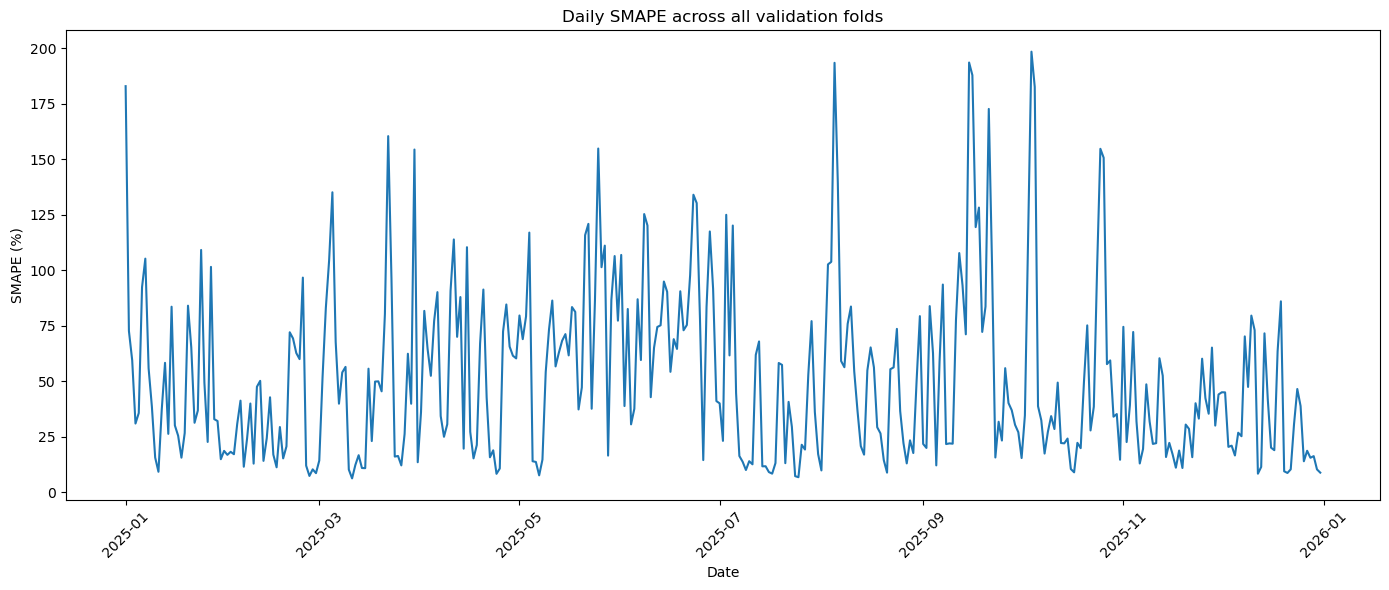

In [17]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from lightgbm import LGBMRegressor

# Initialize model:
model = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1
)

# Set price zone and parameters
# ========================
price_zone = "DK1"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "n_estimators": 200,
    "learning_rate": 0.01,
    "num_leaves": 15,            
    "max_depth": -1,
    "min_child_samples": 1,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 1.0,
    "reg_alpha": 0.0,
    "reg_lambda": 0.0
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)

numeric_cols = feature_predictions.columns.difference(["Time", "DKZone"])
feature_predictions[numeric_cols] = feature_predictions[numeric_cols].apply(
    lambda col: pd.to_numeric(col.astype(str).str.replace(",", "."), errors="coerce")
)

results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models = rf_models,
    use_precomputed_feature_values = use_precomputed_feature_values,
    precomputed_feature_predictions = feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "New_Eval")
base_filename = f"{price_zone}_LightGBM_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = f"{base_filename}_{counter}.csv"
    filename = os.path.join(folder, filename)
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_LightGBM_predictions.csv"),
    index=False,
    decimal=","
)

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004938 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6509
[LightGBM] [Info] Number of data points in the train set: 26304, number of used features: 33
[LightGBM] [Info] Start training from score 898.735589
Model trained in 1.73s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 397.038

Average MAE across all weeks in all folds: 332.155

Average SMAPE across all weeks in all folds: 69.434


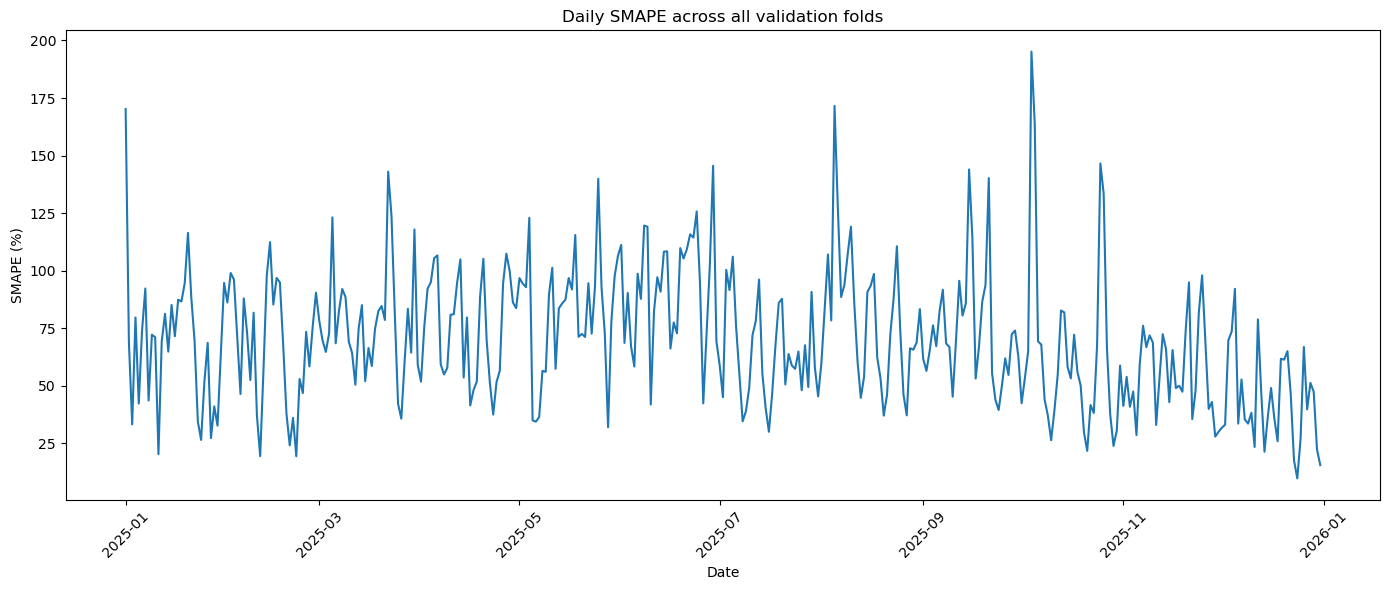

In [18]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from lightgbm import LGBMRegressor

# Initialize model:
model = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1
)

# Set price zone and parameters
# ========================
price_zone = "DK2"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "n_estimators": 200,
    "learning_rate": 0.01,
    "num_leaves": 127,            
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 1.0,
    "reg_alpha": 0.0,
    "reg_lambda": 0.0
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)

numeric_cols = feature_predictions.columns.difference(["Time", "DKZone"])
feature_predictions[numeric_cols] = feature_predictions[numeric_cols].apply(
    lambda col: pd.to_numeric(col.astype(str).str.replace(",", "."), errors="coerce")
)

results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models = rf_models,
    use_precomputed_feature_values = use_precomputed_feature_values,
    precomputed_feature_predictions = feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "New_Eval")
base_filename = f"{price_zone}_LightGBM_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = f"{base_filename}_{counter}.csv"
    filename = os.path.join(folder, filename)
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_LightGBM_predictions.csv"),
    index=False,
    decimal=","
)

## Linear Regression

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36
Model trained in 2.77s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 298.948

Average MAE across all weeks in all folds: 226.646

Average SMAPE across all weeks in all folds: 53.449


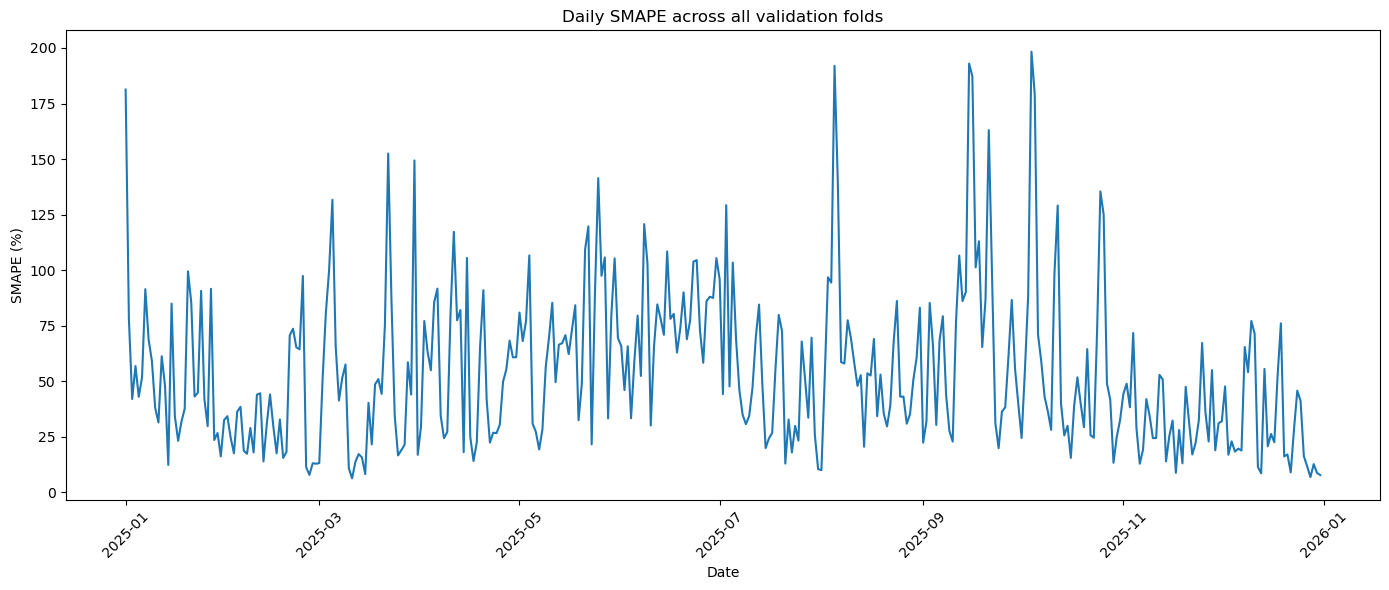

In [19]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Initialize model:
model = Lasso(max_iter=5000)

# Set price zone and parameters
# ========================
price_zone = "DK1"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    'alpha': 0.0001
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models = rf_models,
    use_precomputed_feature_values = use_precomputed_feature_values,
    precomputed_feature_predictions = feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "New_Eval")
base_filename = f"{price_zone}_Lasso_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_Lasso_predictions.csv"),
    index=False,
    decimal=","
)

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36
Model trained in 0.08s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 437.178

Average MAE across all weeks in all folds: 365.040

Average SMAPE across all weeks in all folds: 84.216


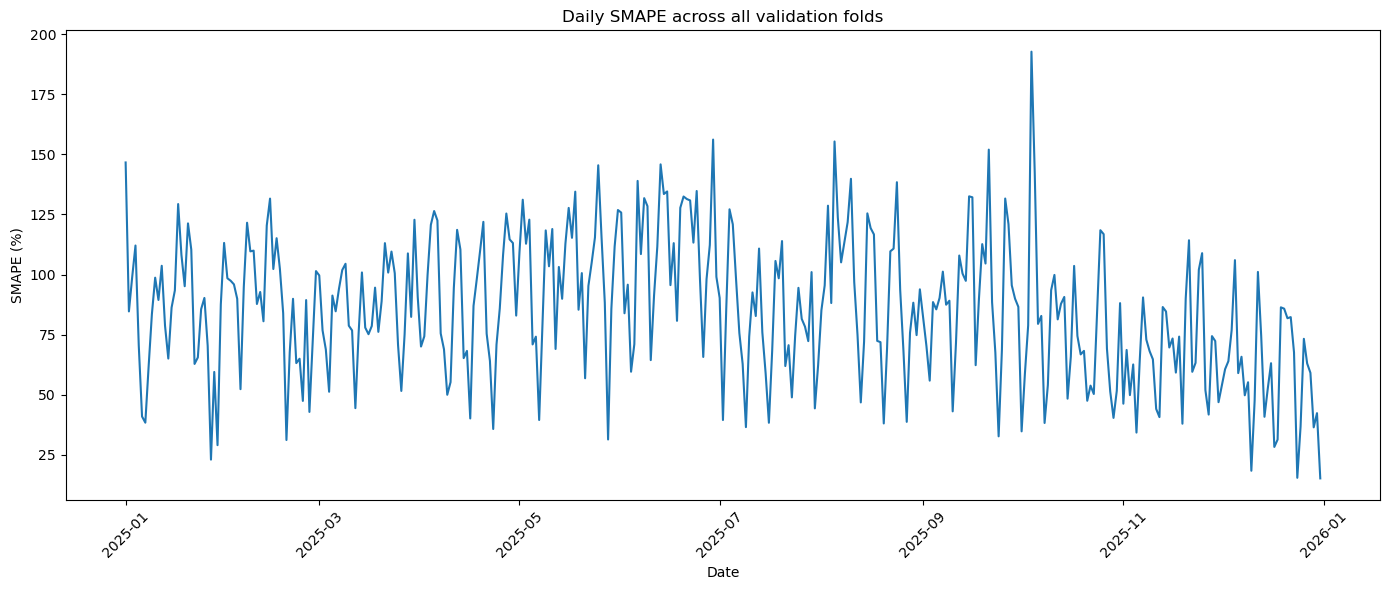

TypeError: unsupported operand type(s) for /: 'str' and 'str'

In [ ]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Initialize model:
model = Lasso(max_iter=5000)

# Set price zone and parameters
# ========================
price_zone = "DK2"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    'alpha': 50
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models = rf_models,
    use_precomputed_feature_values = use_precomputed_feature_values,
    precomputed_feature_predictions = feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
base_filename = f"{price_zone}_Lasso_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = f"{filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_Lasso_predictions.csv"),
    index=False,
    decimal=","
)

In [22]:
# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "New_Eval")
base_filename = f"{price_zone}_Lasso_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = f"{filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_Lasso_predictions.csv"),
    index=False,
    decimal=","
)

## XGBoost

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36
Model trained in 14.16s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 286.444

Average MAE across all weeks in all folds: 217.773

Average SMAPE across all weeks in all folds: 52.245


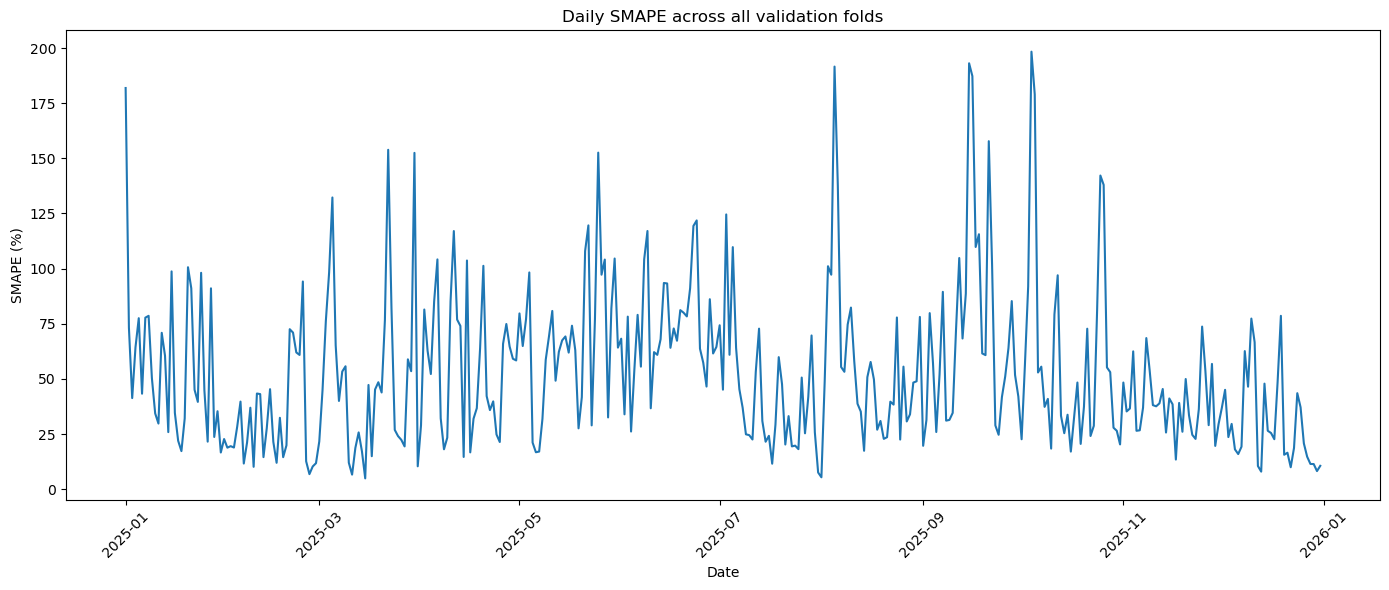

In [23]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from xgboost import XGBRegressor

# Initialize model:
model = XGBRegressor()

# Set price zone and parameters
# ========================
price_zone = "DK1"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "max_depth": 5,
    "learning_rate": 0.05,
    "n_estimators": 400,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models = rf_models,
    use_precomputed_feature_values = use_precomputed_feature_values,
    precomputed_feature_predictions = feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "New_Eval")
base_filename = f"{price_zone}_XGBoost_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_XGBoost_predictions.csv"),
    index=False,
    decimal=","
)

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36
Model trained in 14.14s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 428.392

Average MAE across all weeks in all folds: 362.993

Average SMAPE across all weeks in all folds: 78.989


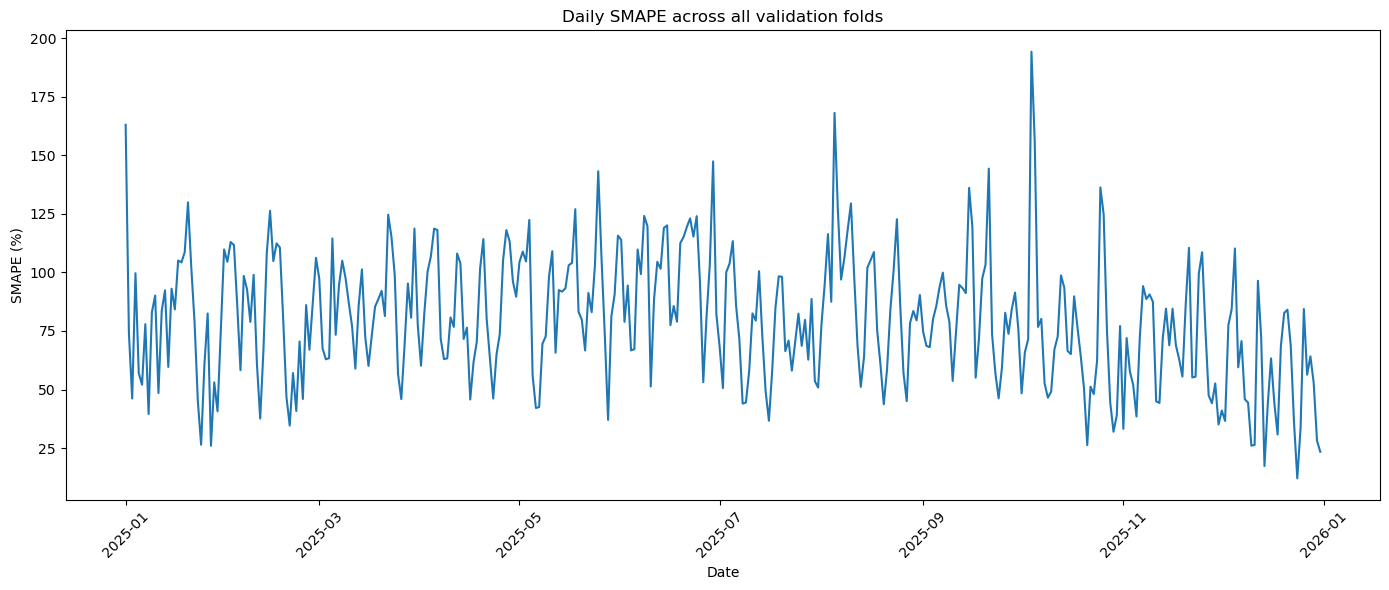

: 

In [ ]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from xgboost import XGBRegressor

# Initialize model:
model = XGBRegressor()

# Set price zone and parameters
# ========================
price_zone = "DK2"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "max_depth": 7,
    "learning_rate": 0.05,
    "n_estimators": 400,
    "subsample": 1.0,
    "colsample_bytree": 0.7,
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models = rf_models,
    use_precomputed_feature_values = use_precomputed_feature_values,
    precomputed_feature_predictions = feature_predictions,
    use_forecasted_history=True
)
# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "New_Eval")
base_filename = f"{price_zone}_XGBoost_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_XGBoost_predictions.csv"),
    index=False,
    decimal=","
)

## Support Vector Regression

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36
Model trained in 28.35s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 383.897

Average MAE across all weeks in all folds: 292.181

Average SMAPE across all weeks in all folds: 54.129


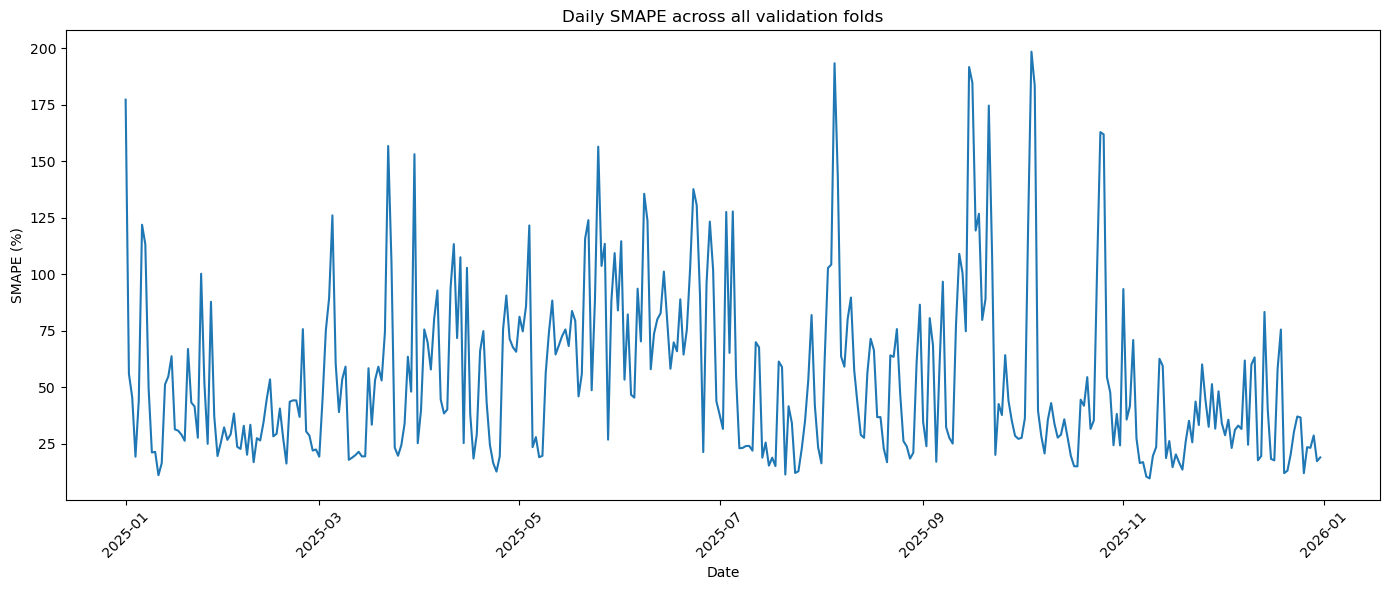

In [7]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from sklearn.svm import SVR

# Initialize model:
model = SVR()

# Set price zone and parameters
# ========================
price_zone = "DK1"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "kernel": "poly",
    "C": 0.1,
    "gamma": "auto",
    "epsilon": 0.1,
    "degree": 2,
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=True,
    print_fold_results=False,
    plot=True,
    rf_models = rf_models,
    use_precomputed_feature_values = use_precomputed_feature_values,
    precomputed_feature_predictions = feature_predictions,
    use_forecasted_history=True
)
# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "New_Eval")
base_filename = f"{price_zone}_SVR_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_SVR_predictions.csv"),
    index=False,
    decimal=","
)

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36
Model trained in 35.94s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 330.483

Average MAE across all weeks in all folds: 255.289

Average SMAPE across all weeks in all folds: 52.240


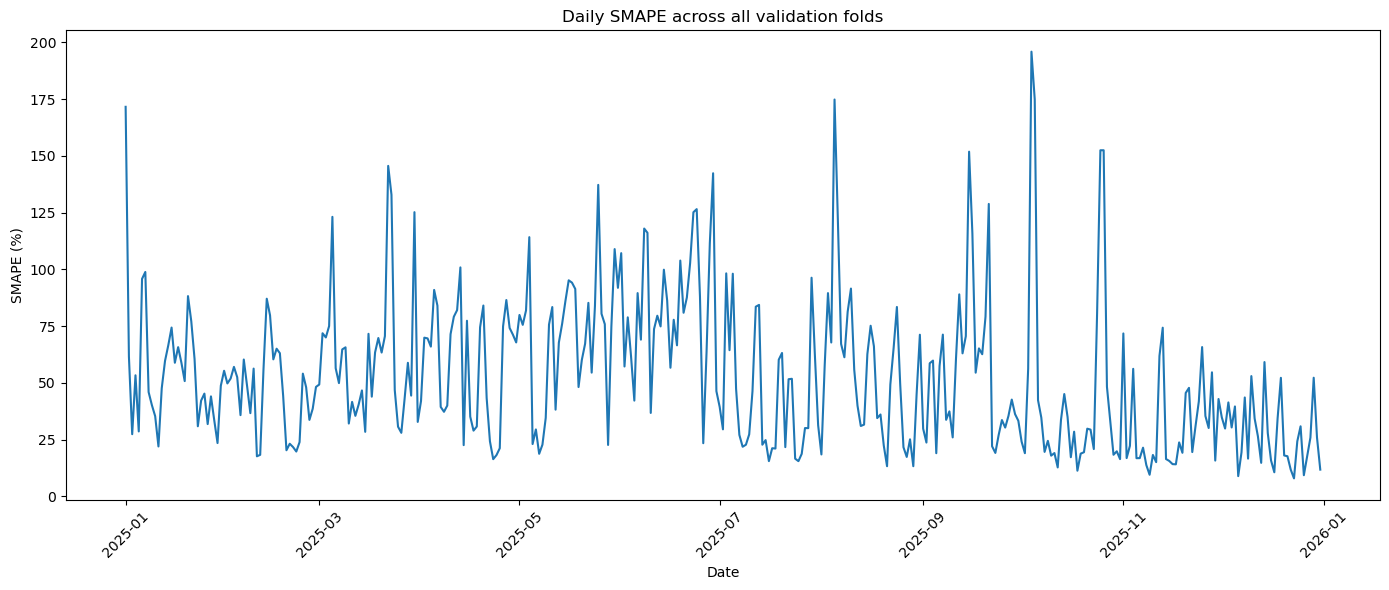

In [8]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from sklearn.svm import SVR

# Initialize model:
model = SVR()

# Set price zone and parameters
# ========================
price_zone = "DK2"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "kernel": "rbf",
    "C": 1.0,
    "gamma": "auto",
    "epsilon": 0.5,
}
# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=True,
    print_fold_results=False,
    plot=True,
    rf_models = rf_models,
    use_precomputed_feature_values = use_precomputed_feature_values,
    precomputed_feature_predictions = feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "New_Eval")
base_filename = f"{price_zone}_SVR_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_SVR_predictions.csv"),
    index=False,
    decimal=","
)